In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df = pd.read_csv("cars_dataframe.csv")

## This notebook is divided into 4 subsections:
* Section 1: EDA: Exploratory Data Analysis
* Section 2: PCA and Dimensionality reduction
* Section 3: Machine learning: Model training
* Section 4: Model evaluation and metrics 

## First challenge: Cleaning this dataset
### Data Quality & Cleaning Questions
How do we deal with N/A values? — Several columns (Origin, Price, Number of Doors) have missing values.
How do we deal with outliers? — e.g., extreme prices or unusual year/mileage combinations.
How do we handle duplicates and missing values ?
When is the dataset considered clean and ready for ML?

## Exploratory Data Analysis: EDA
Given our 15 columns
**Brand, Model, Year, Condition, Mileage, Gearbox, Fiscal Power, Fuel, Equipment, Number of Doors, Origin, First Owner, Location, Sector, Price**
Let's try to answer the following questions:
### Price Analysis (Target Variable)
1. What is the distribution of car prices? — Is it **normal**, **skewed**, **multimodal**? ✅
2. What is the average/median price by Brand? — Which brands command the highest prices? ✅
3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is) ✅

### Feature Relationships (correlation coefficients)
4. How does Mileage impact Price ? Do higher-mileage cars sell for significantly less? (Intuitively, the answer is **yes**)
5. Does Gearbox type (Manual vs. Automatic) affect price? — And is the effect consistent across brands? ✅
6. Does Condition rating correlate with Price as expected? — Fair < Good < Very Good < Excellent? ✅

### Market Composition
7. What are the most common Brands and Models? — Market share distribution. ✅ 
8. What is the distribution of car Years? — Is the market dominated by recent or older cars? ✅
9. What's the split between Manual vs. Automatic gearboxes? ✅
10. What's the Diesel vs. Petrol distribution? ✅

### Geographic Insights
11. Which Locations/cities have the most listings? ✅
12. Do prices vary by Location? ✅
13. Does the Origin (WW in Morocco, Customs-cleared, etc.) affect pricing? ✅

### Ownership & Equipment
14. Does First Owner (Yes/No) affect price? ✅
15. What are the most common Equipment features? ✅
16. Do more equipped cars command higher prices? ✅

### Multivariate / Correlation
17. What are the strongest correlations with Price ? ✅

# Part 1: The data
## Dealing with Missing Data

In [2]:
rows, cols = df.shape
print(f"Dataset: {rows:,} rows × {cols} columns")

Dataset: 101,896 rows × 15 columns


In [3]:
missing = df.isnull().sum()
percent_missing = (missing.sum() / np.prod(df.shape)) * 100
print(f"About {percent_missing:.2f}% of the data is missing")
print(missing[missing > 0])

About 4.43% of the data is missing
Brand                  1
Model                  1
Condition           3583
Mileage                1
Fiscal Power         280
Number of Doors    11415
Origin             11975
First Owner        14700
Sector               246
Price              25483
dtype: int64


## The Missing Data Map

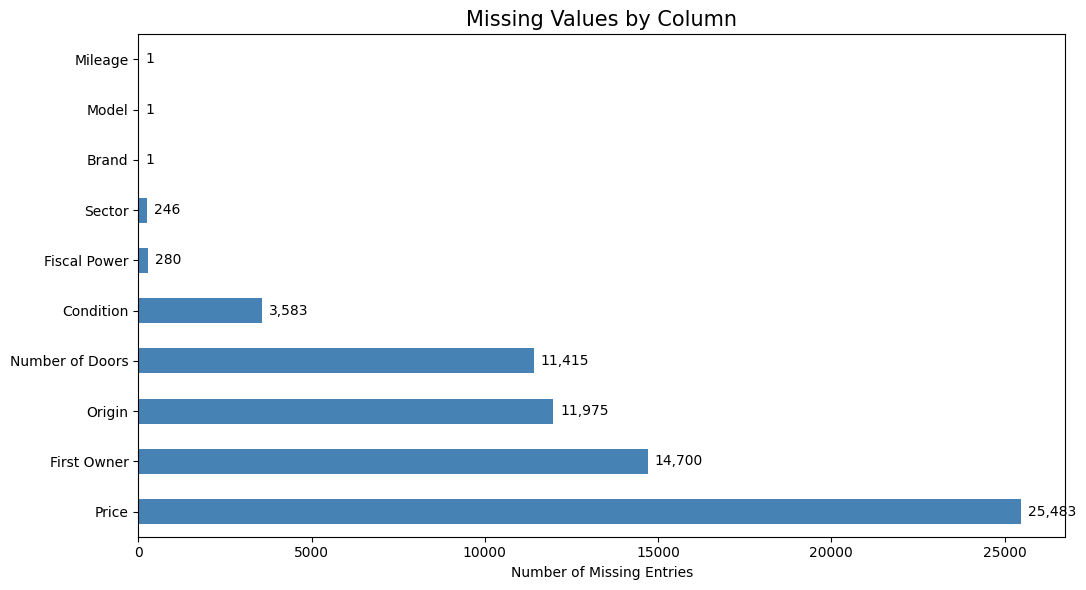

In [4]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
missing_data.plot.barh(ax=ax, color='steelblue')
ax.set_title("Missing Values by Column", fontsize=15)
ax.set_xlabel("Number of Missing Entries")
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

## Q: What do we do with cars that have no Price?

> **Answer:** Drop them! `Price` is our target variable — without it, a record is useless.

In [5]:
missing_price_before = df['Price'].isnull().sum()
df = df.dropna(subset=['Price'])
print(f"Dropped {missing_price_before} rows with missing Price")
print(f"Remaining rows: {df.shape[0]:,}")
assert df['Price'].isnull().sum() == 0

Dropped 25483 rows with missing Price
Remaining rows: 76,413


## Q: What about the Number of Doors?

> **Answer:** We can **infer** it! Cars of the same Brand, Model, and Year almost always share the same door count.

In [6]:
def fill_doors(df):
    col = 'Number of Doors'
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])
    mode_bm  = group_mode(['Brand', 'Model'])
    mode_b   = group_mode(['Brand'])
    overall_mode = df[col].mode().iloc[0]

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        for key, lookup in [
            ((row['Brand'], row['Model'], row['Year']), mode_bmy),
            ((row['Brand'], row['Model']), mode_bm),
            (row['Brand'], mode_b),
        ]:
            try:
                val = lookup.loc[key]
                if pd.notna(val): return val
            except KeyError:
                pass
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    # Ensure the column type is int64
    df[col] = df[col].astype('int64')
    return df

df = fill_doors(df)
print(f"Missing 'Number of Doors' after imputation: {df['Number of Doors'].isnull().sum()}")

Missing 'Number of Doors' after imputation: 0


## Q: What about the other columns?

| Column | Strategy | Why |
|---|---|---|
| `Condition` | **Drop** rows | Can't reliably infer condition |
| `Origin` | **Fill** → `"Unknown"` | Better than losing the row |
| `First Owner` | **Fill** → `"Unknown"` | Could be any owner |
| `Sector` | **Fill** → `"Unknown"` | Optional metadata |
| `Brand / Model` | **Drop** the one bad row (#6714) | No way to recover |

In [7]:
df = df.dropna(subset=['Condition'])
df['Origin'] = df['Origin'].fillna('Unknown')
df['First Owner'] = df['First Owner'].fillna('Unknown')
df['Sector'] = df['Sector'].fillna('Unknown')
df = df.drop(index=6714, errors='ignore')
df.drop_duplicates(inplace=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
df = df[~df['Brand'].str.isnumeric()]
print(f"Clean dataset shape: {df.shape}")

Clean dataset shape: (72239, 15)


## Q: What about the Location column?

> **Problem:** Some locations are in French whilst others are in Arabic.
> **Answer:** We need to make this data uniform!

In [8]:
city_mapping = {
    "الدار البيضاء": "Casablanca",
    "الرباط": "Rabat",
    "فاس": "Fès",
    "مراكش": "Marrakech",
    "طنجة": "Tanger",
    "أكادير": "Agadir",
    "وجدة": "Oujda",
    "القنيطرة": "Kénitra",
    "تطوان": "Tétouan",
    "آسفي": "Safi",
    "الجديدة": "El Jadida",
    "العرائش": "Larache",
    "خريبكة": "Khouribga",
    "بني ملال": "Beni Mellal",
    "الناظور": "Nador",
    "العيون": "Laâyoune",
    "الداخلة": "Dakhla",
    "المحمدية": "Mohammedia",
    "مكناس": "Meknès",
    "تمارة": "Temara"
}

df["Location"] = df["Location"].map(city_mapping).fillna(df["Location"])
print(f"Total unique locations after mapping: {df['Location'].nunique()}")

Total unique locations after mapping: 364


## Renaming columns for easier use

In [9]:
new_names_mapping = {'Number of Doors': 'NoD', 'First Owner': 'FO'}
df.rename(columns=new_names_mapping, inplace=True)

## Q: What about fiscal power?

> **Answer:** We can **infer** it! Cars of the same Brand, Model, and Year almost always share the same fiscal power.

In [10]:
def fill_fiscal_power(df):
    col = 'Fiscal Power'
    
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])   # most specific
    mode_bm  = group_mode(['Brand', 'Model'])           # fallback 1
    mode_b   = group_mode(['Brand'])                    # fallback 2
    overall_mode = df[col].mode().iloc[0]               # fallback 3

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        for key, lookup in [
            ((row['Brand'], row['Model'], row['Year']), mode_bmy),
            ((row['Brand'], row['Model']), mode_bm),
            (row['Brand'], mode_b),
        ]:
            try:
                val = lookup.loc[key]
                if pd.notna(val): return val
            except KeyError:
                pass
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    return df

df = fill_fiscal_power(df)
print(f"Missing 'Fiscal Power' after imputation: {df['Fiscal Power'].isnull().sum()}")
assert df['Fiscal Power'].isnull().sum() == 0

Missing 'Fiscal Power' after imputation: 0


## The Dataset is Now Clean!

In [11]:
missing_after = df.isnull().sum()
total_missing = missing_after[missing_after > 0]
if total_missing.empty:
    print("Zero missing values remaining!")
    print(df.info())
    print(f"We are left with: {df.shape[0]} rows and {df.shape[1]} columns")
else:
    print(total_missing)

Zero missing values remaining!
<class 'pandas.core.frame.DataFrame'>
Index: 72239 entries, 0 to 101892
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         72239 non-null  object 
 1   Model         72239 non-null  object 
 2   Year          72239 non-null  int64  
 3   Condition     72239 non-null  object 
 4   Mileage       72239 non-null  object 
 5   Gearbox       72239 non-null  object 
 6   Fiscal Power  72239 non-null  object 
 7   Fuel          72239 non-null  object 
 8   Equipment     72239 non-null  object 
 9   NoD           72239 non-null  int64  
 10  Origin        72239 non-null  object 
 11  FO            72239 non-null  object 
 12  Location      72239 non-null  object 
 13  Sector        72239 non-null  object 
 14  Price         72239 non-null  float64
dtypes: float64(1), int64(2), object(12)
memory usage: 8.8+ MB
None
We are left with: 72239 rows and 15 columns


# Part 2: The Price Enigma
## Q1: What does the price distribution look like?

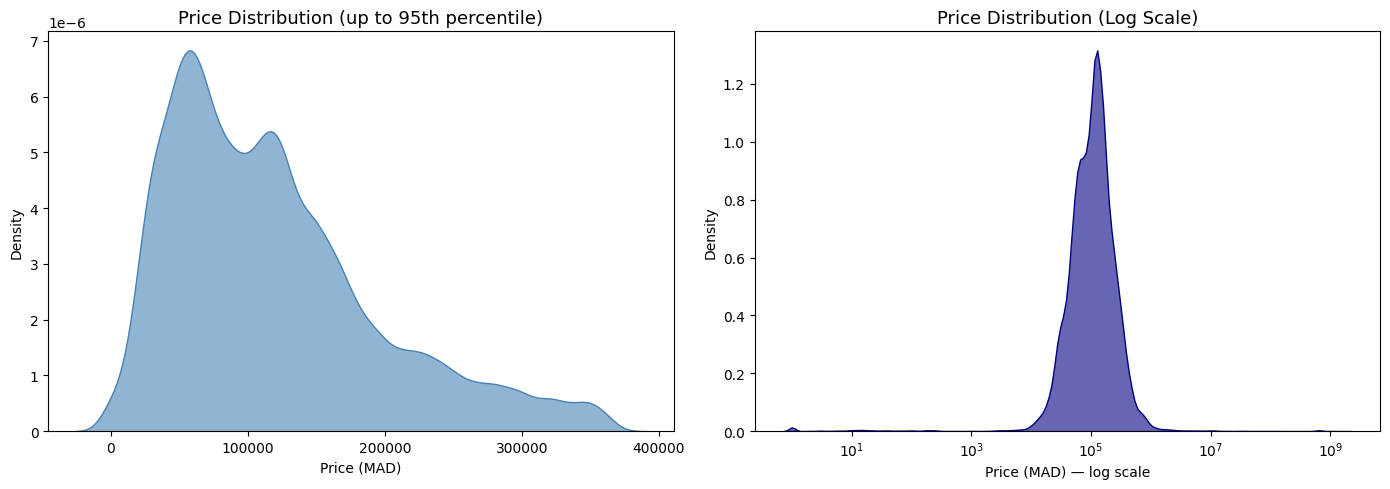

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

upper = df['Price'].quantile(0.95)
sns.kdeplot(data=df[df['Price'] <= upper], x='Price', fill=True,
            color='steelblue', alpha=0.6, ax=axes[0])
axes[0].set_title('Price Distribution (up to 95th percentile)', fontsize=13)
axes[0].set_xlabel('Price (MAD)')

sns.kdeplot(data=df, x='Price', fill=True, color='navy', alpha=0.6,
            ax=axes[1], log_scale=True)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('Price (MAD) — log scale')

plt.tight_layout()
plt.show()

## Q2: Which brands command the highest prices?

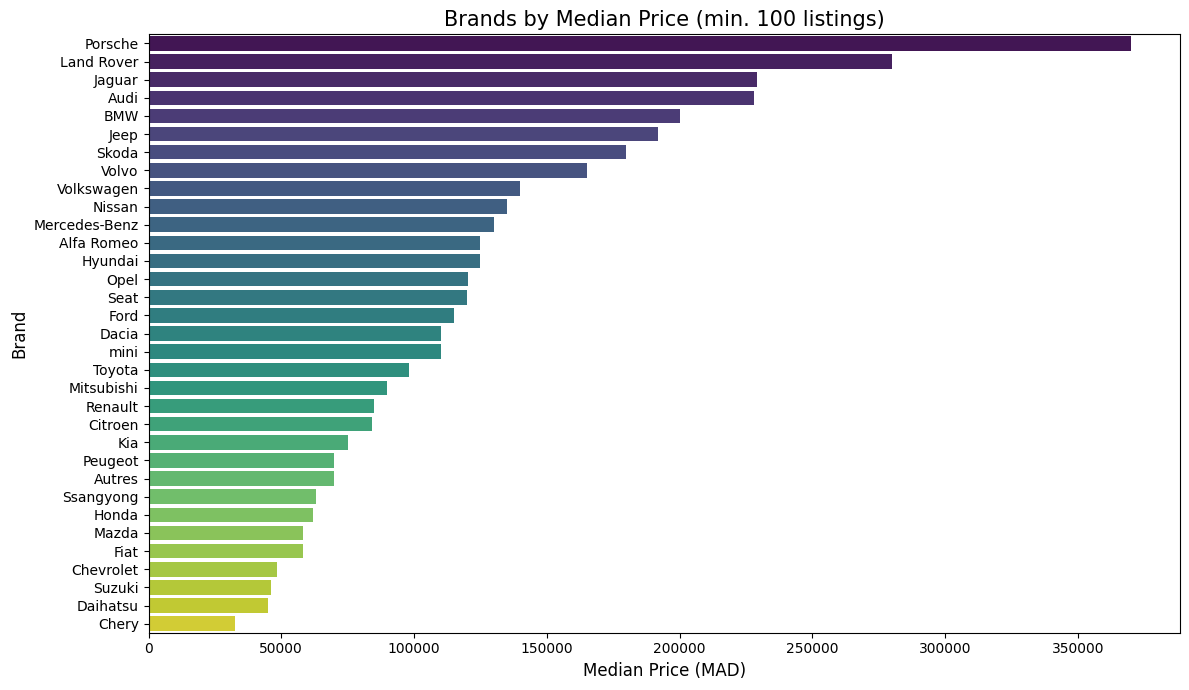

In [13]:
brand_counts = df['Brand'].value_counts()
popular_brands = brand_counts[brand_counts >= 100].index
df_popular = df[df['Brand'].isin(popular_brands)]

median_price = df_popular.groupby('Brand')['Price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=median_price.values, y=median_price.index,
            hue=median_price.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Brands by Median Price (min. 100 listings)', fontsize=15)
ax.set_xlabel('Median Price (MAD)', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.show()

## Q3: Does the year affect the price?

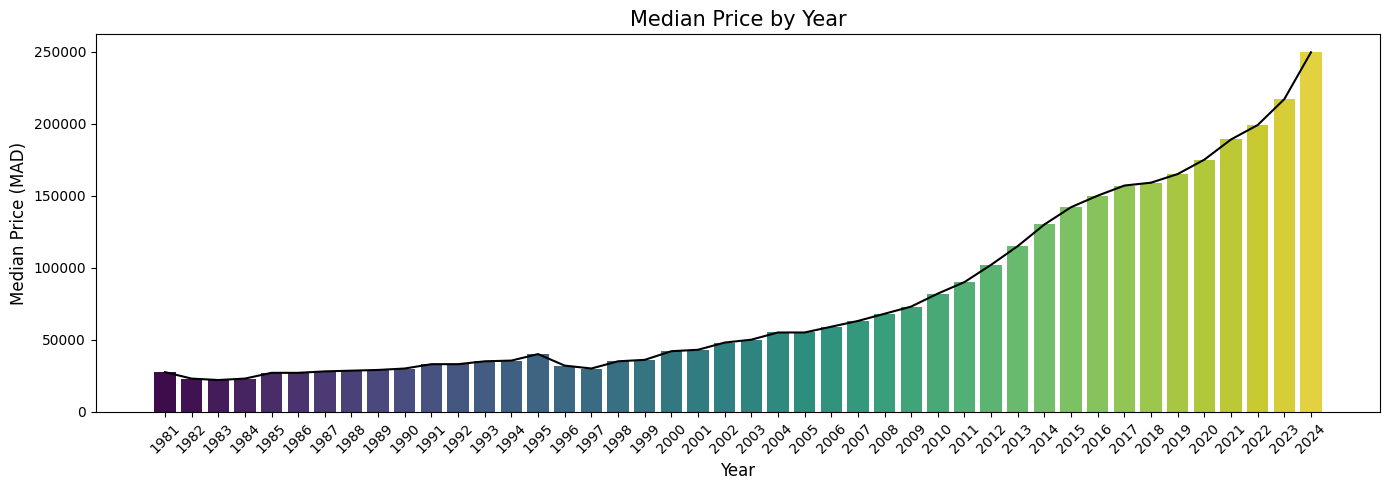

In [14]:
median_by_year = df.groupby('Year')['Price'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=median_by_year, x='Year', y='Price', hue='Year', palette='viridis', legend=False, ax=ax)
ax.plot(range(len(median_by_year)), median_by_year['Price'], color='black', marker=None, linestyle='-', linewidth=1.5)
ax.set_title('Median Price by Year', fontsize=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Q4: Manual vs. Automatic — Who pays more?

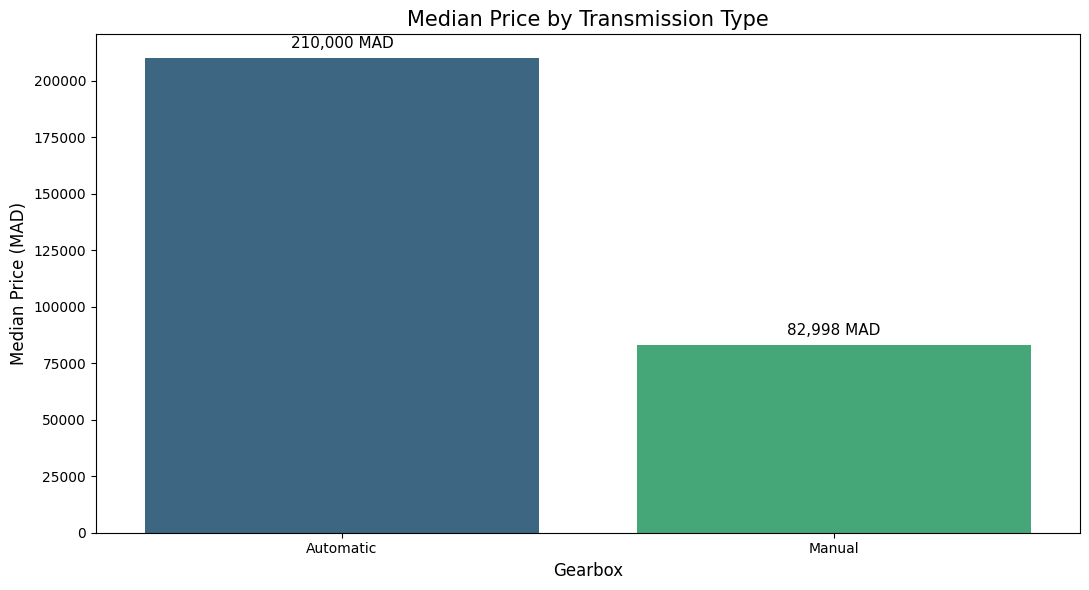

In [15]:
median_price_by_gearbox = df.groupby('Gearbox')['Price'].median().reset_index()
median_price_by_gearbox = median_price_by_gearbox.sort_values(by='Price', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=median_price_by_gearbox, x='Gearbox', y='Price',
            hue='Gearbox', legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by Transmission Type', fontsize=15)
ax.set_xlabel('Gearbox', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f} MAD",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()

## Q5: Does Condition match our expectations?

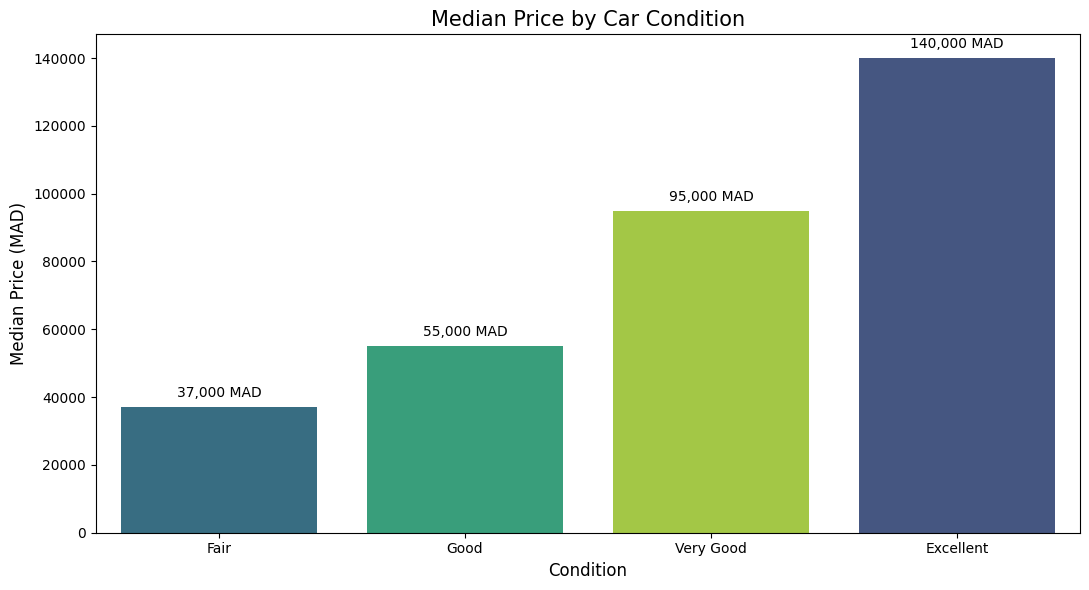

In [16]:
median_price_by_condition = df.groupby('Condition')['Price'].median().reset_index()
condition_order = ['Fair', 'Good', 'Very Good', 'Excellent']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=median_price_by_condition, x='Condition', y='Price',
            hue='Condition', order=condition_order, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by Car Condition', fontsize=15)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f} MAD",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()

# Part 3: The Market Map
## Q6: Who dominates the market?

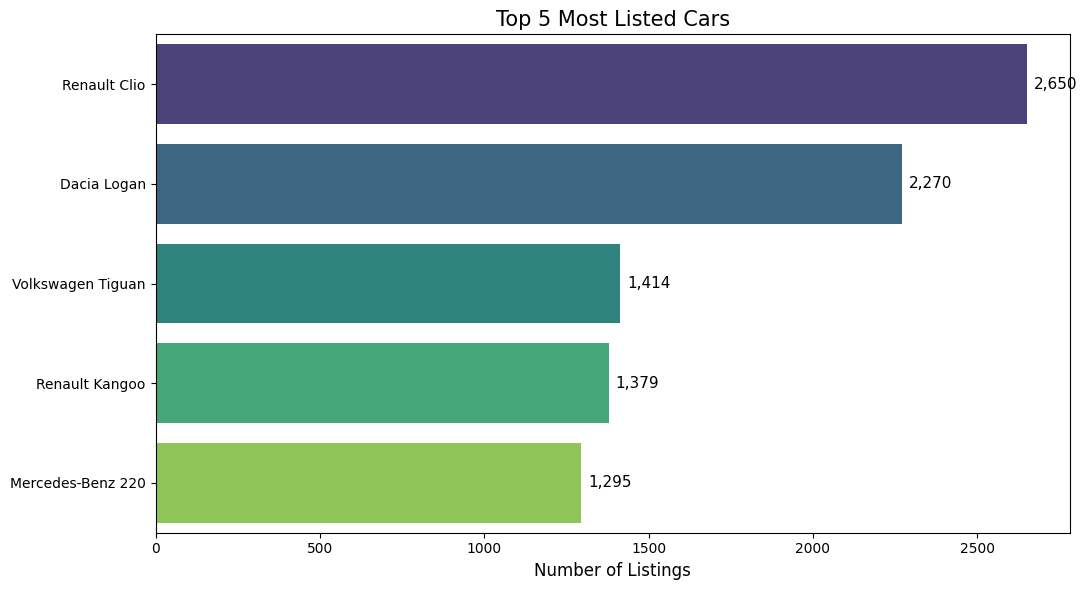

In [17]:
df_plot = df.copy()
df_plot['Car'] = df_plot['Brand'] + ' ' + df_plot['Model']
top_5_cars = df_plot['Car'].value_counts().head(5).reset_index()
top_5_cars.columns = ['Car', 'Count']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_5_cars, x='Count', y='Car', hue='Car', legend=False, palette='viridis', ax=ax)
ax.set_title('Top 5 Most Listed Cars', fontsize=15)
ax.set_xlabel('Number of Listings', fontsize=12)
ax.set_ylabel('')

for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, xytext=(5, 0),
                textcoords='offset points')
plt.tight_layout()
plt.show()

## Q7: Old cars or New cars?

> *We consider New = After 2020. Old = 2020 and before.*

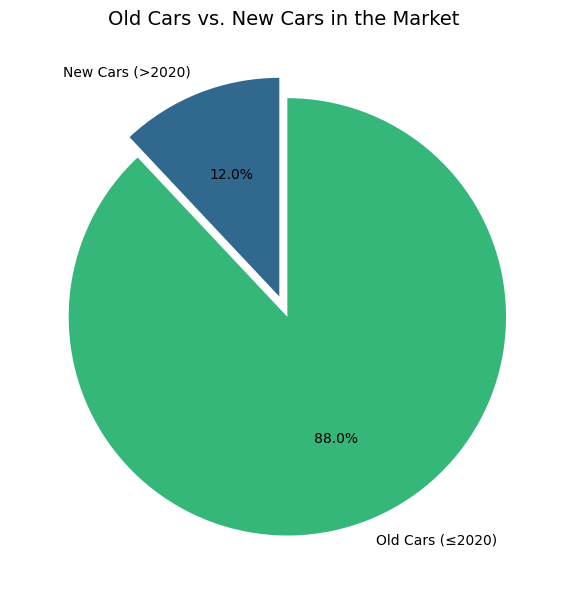

In [18]:
new_cars = df[df['Year'] > 2020]
old_cars = df[df['Year'] <= 2020]

df_counts = pd.Series(
    [new_cars.shape[0], old_cars.shape[0]],
    index=['New Cars (>2020)', 'Old Cars (≤2020)']
)

fig, ax = plt.subplots(figsize=(6, 6))
df_counts.plot.pie(autopct='%1.1f%%',
    colors=sns.color_palette('viridis', 2), startangle=90, explode=(0.05, 0.05), ax=ax)
ax.set_ylabel('')
ax.set_title('Old Cars vs. New Cars in the Market', fontsize=14)
plt.tight_layout()
plt.show()

## Q8: Manual or Automatic?

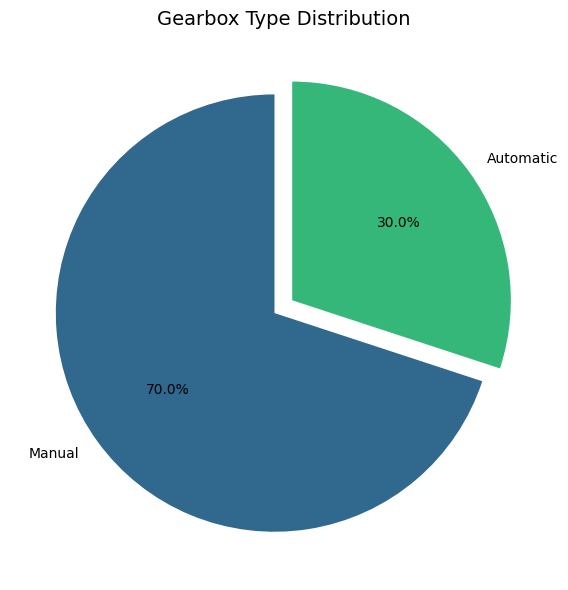

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
df['Gearbox'].value_counts().plot.pie(autopct='%1.1f%%',
    colors=sns.color_palette('viridis', 2), startangle=90, explode=(0.05, 0.05), ax=ax)
ax.set_ylabel('')
ax.set_title('Gearbox Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()

## Q9: Diesel or Petrol?

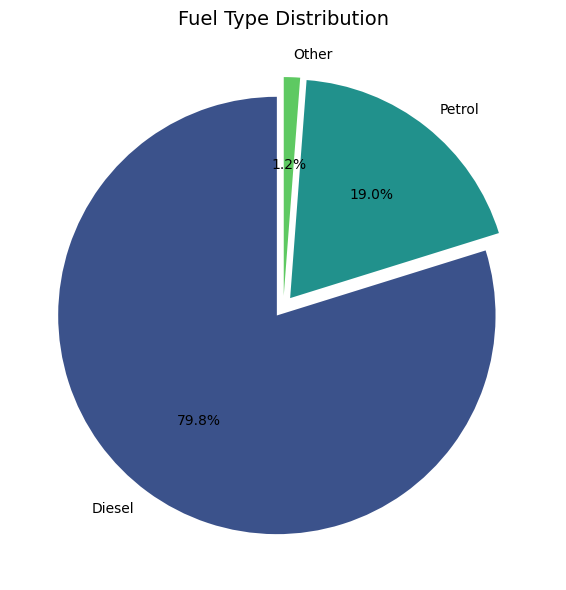

In [20]:
## Since Diesel and Petrol are predominant, let's squash the other categories into 'Other'
fuel_counts = df['Fuel'].value_counts()
fuel_counts['Other'] = fuel_counts[~fuel_counts.index.isin(['Diesel', 'Petrol'])].sum()
fuel_counts = fuel_counts[['Diesel', 'Petrol', 'Other']]

fig, ax = plt.subplots(figsize=(6, 6))
fuel_counts.plot.pie(autopct='%1.1f%%',
    colors=sns.color_palette('viridis', 3), startangle=90, explode=[0.05] * 3, ax=ax)
ax.set_ylabel('')
ax.set_title('Fuel Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Part 4: The Geographic Trail
## Q10: Where are all these cars coming from?

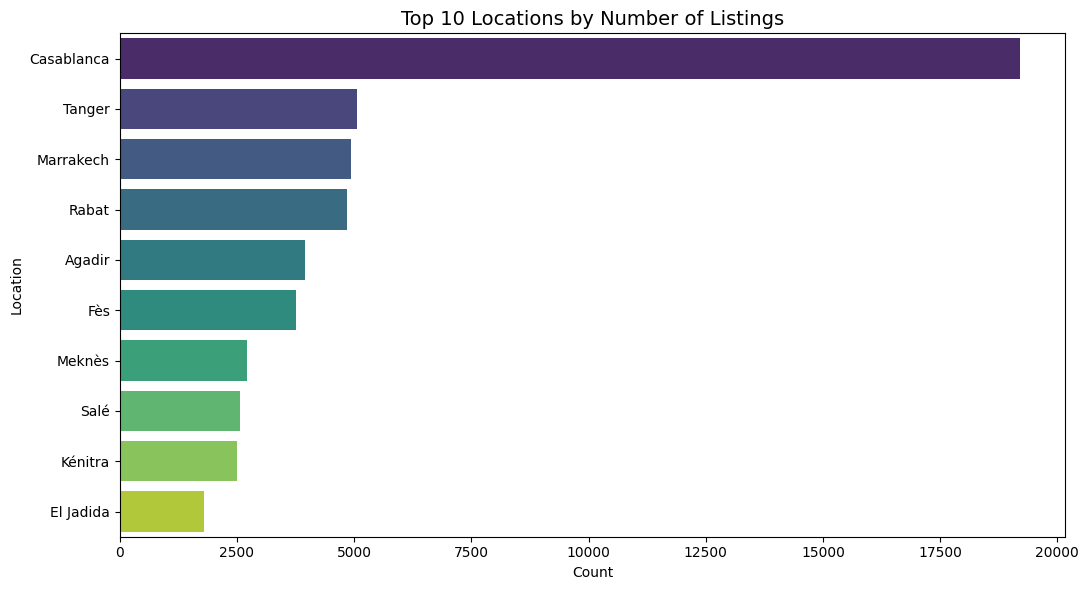

In [21]:
loc_counts = df['Location'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=loc_counts.values, y=loc_counts.index,
            hue=loc_counts.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Top 10 Locations by Number of Listings', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Location')
plt.tight_layout()
plt.show()

## Q11: Where are the most expensive cars?

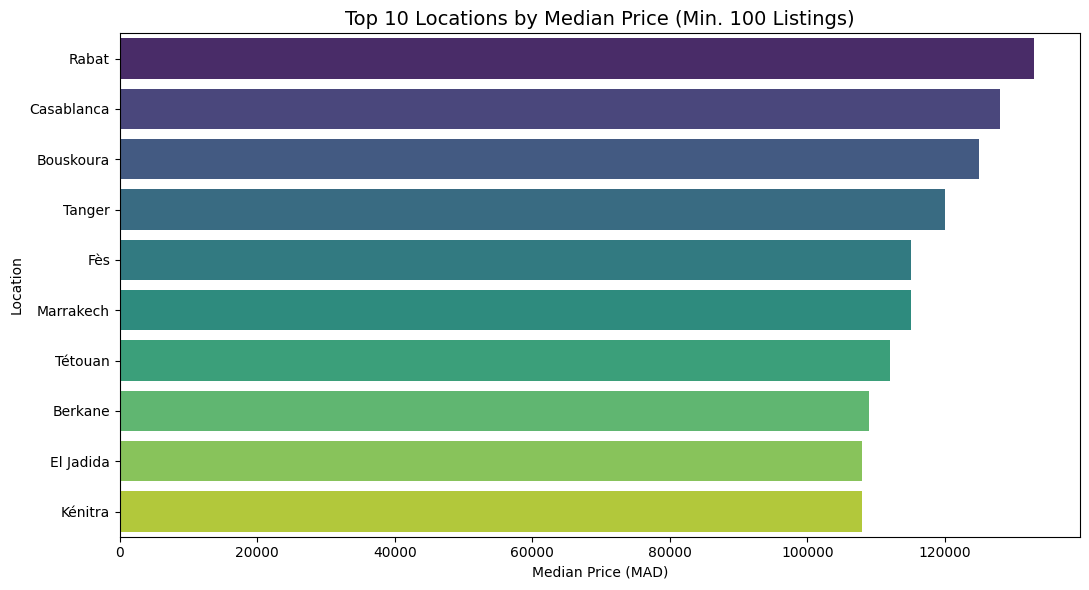

In [22]:
# First, filter to locations that have at least 100 listings
threshold = 100
loc_counts = df['Location'].value_counts()
popular_locs = loc_counts[loc_counts >= threshold].index
df_popular_loc = df[df['Location'].isin(popular_locs)]

median_price_loc = df_popular_loc.groupby('Location')['Price'].median().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=median_price_loc.values, y=median_price_loc.index,
            hue=median_price_loc.index, legend=False, palette='viridis', ax=ax)
ax.set_title(f'Top 10 Locations by Median Price (Min. {threshold} Listings)', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('Location')
plt.tight_layout()
plt.show()

## Q12: Does the Origin affect price?

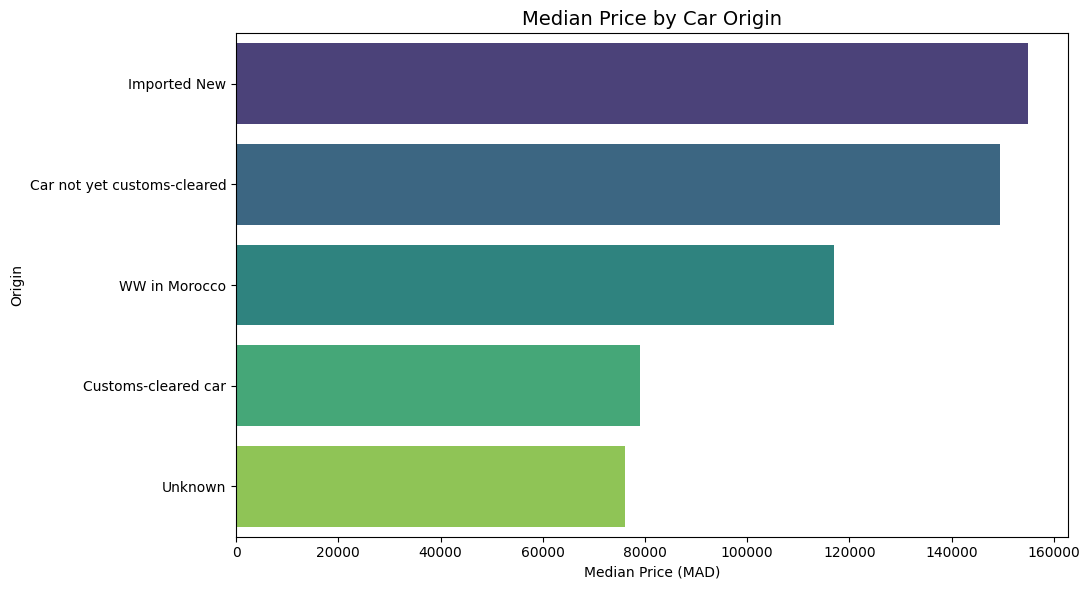

In [23]:
median_price_origin = df.groupby('Origin')['Price'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=median_price_origin.values, y=median_price_origin.index,
            hue=median_price_origin.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by Car Origin', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('Origin')

plt.tight_layout()
plt.show()

# Part 5: The Hidden Factors
## Q13: Does being First Owner matter?

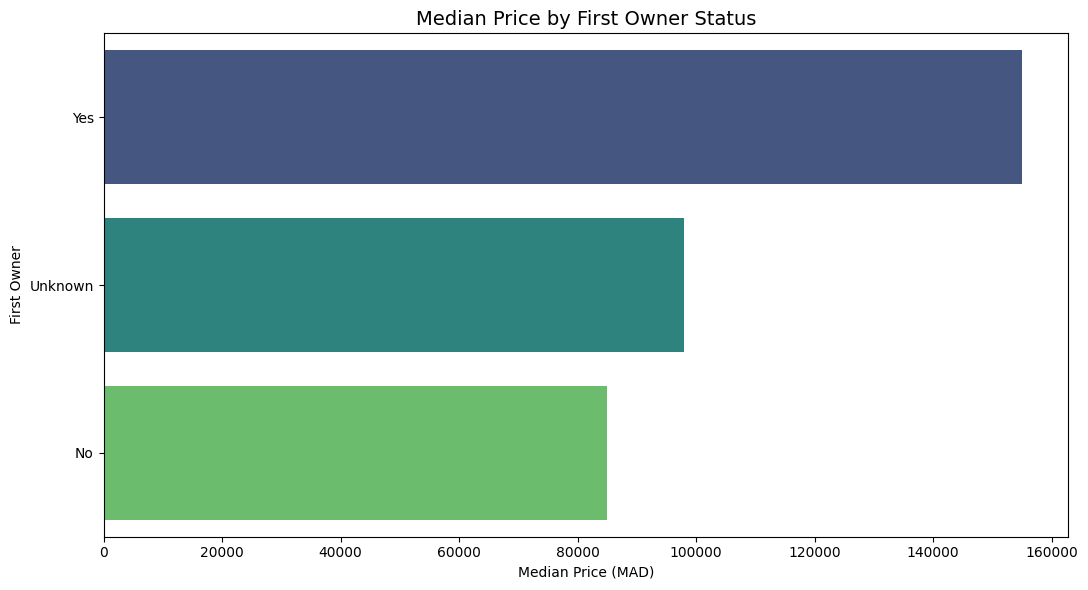

In [24]:
median_price_owner = df.groupby('FO')['Price'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=median_price_owner.values, y=median_price_owner.index,
            hue=median_price_owner.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by First Owner Status', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('First Owner')
plt.tight_layout()
plt.show()

## Q14: What equipment features are most common?

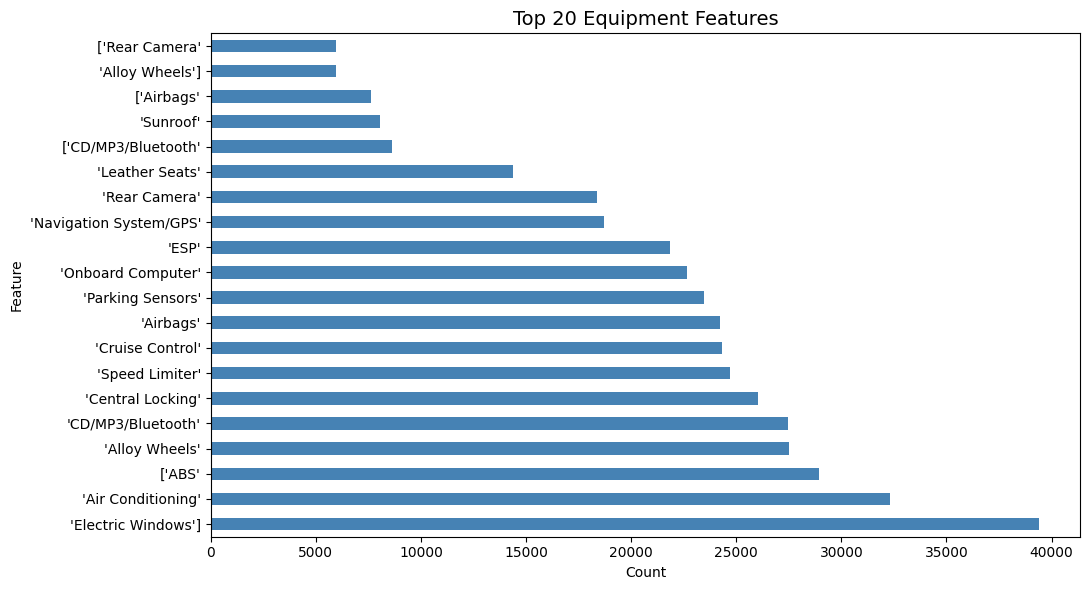

In [25]:
equip_series = df['Equipment'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
equip_series.head(20).plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 Equipment Features', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## Q15: Do more features = higher price?

Correlation (# of features vs price): -0.009


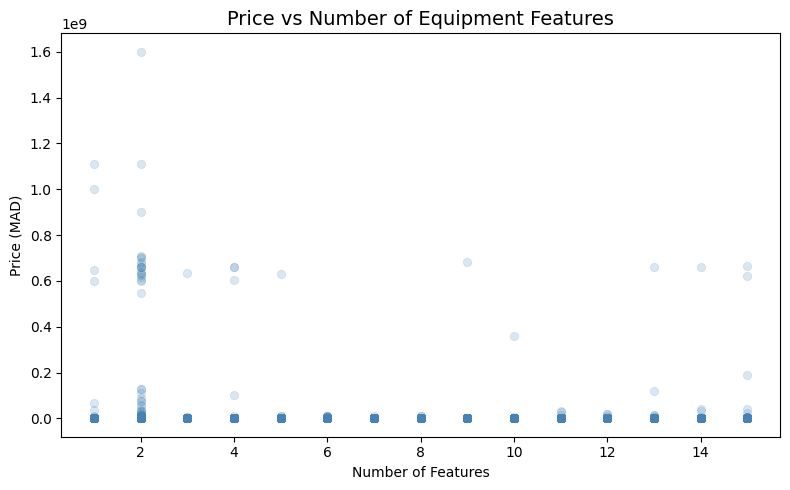

In [26]:
df['num_features'] = df['Equipment'].fillna('').apply(
    lambda s: len([x for x in s.split(',') if x.strip() != ''])
)
corr = df['num_features'].corr(df['Price'])
print(f"Correlation (# of features vs price): {corr:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='num_features', y='Price', alpha=0.2,
                edgecolor=None, color='steelblue', ax=ax)
ax.set_title('Price vs Number of Equipment Features', fontsize=14)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Price (MAD)')
plt.tight_layout()
plt.show()

# Part 6: The Big Picture
## Q16: What actually correlates with price?

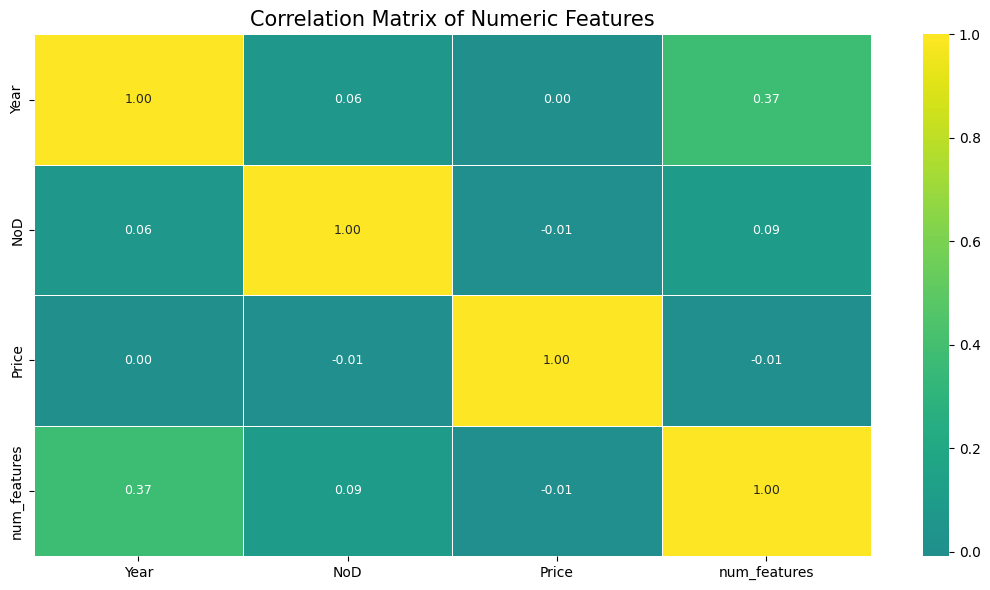

In [27]:
numeric = df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()

plt.figure(figsize=(11, 6))
sns.heatmap(corr_matrix, cmap='viridis', center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Correlation Matrix of Numeric Features', fontsize=15)
plt.tight_layout()
plt.show()

# Saving the Cleaned Data

Let's save our squeaky clean dataset before moving on to the next chapter!

In [28]:
df.to_csv("cleaned_data.csv", index=False)
print("Dataset successfully saved as 'cleaned_data.csv'!")

Dataset successfully saved as 'cleaned_data.csv'!
